# Clarke-Wright VRPTW — Instance Marocaine (Casablanca)

Lit directement `instance_maroc_vrptw_50c.dzn` et applique Clarke-Wright en respectant :
- **Flotte hétérogène** : Triporteur (300kg) / Fourgonnette (1200kg) / Camion (5000kg)
- **Zones restreintes** : `acces_autorise[v, c]` = 0 interdit le véhicule v au client c
- **Fenêtres de temps** : `early`, `late`, `service`
- **Trafic dynamique** : matrice `temps_trajet` moyenne (pondération 4 créneaux)

Output comparable avec MiniZinc CP+LNS.

In [10]:
import re
import numpy as np
import matplotlib.pyplot as plt
import time
import csv
import os

print('Libraries OK')

Libraries OK


## 1. Parsing du fichier .dzn marocain

In [11]:
def parse_maroc_dzn(filepath):
    """
    Parse instance_maroc_vrptw.dzn
    Structure differente des Solomon :
      - num_clients, num_vehicules
      - demande[1..n+1] (index 1=depot)
      - capacite_vehicule[1..K] (flotte heterogene)
      - type_vehicule[1..K]
      - acces_autorise[v, c] matrice K x n
      - 4 matrices temps : temps_trajet_c0..c3
    """
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        raw = f.read()

    text = re.sub(r'%.*', '', raw).replace('\r', ' ')

    def get_int(name):
        m = re.search(rf'\b{name}\s*=\s*(\d+)', text)
        return int(m.group(1)) if m else None

    def get_flat_array(name):
        """Extrait un tableau [v1, v2, ...]"""
        m = re.search(rf'\b{name}\s*=\s*\[([^\]]+)\]', text, re.DOTALL)
        if not m:
            return None
        return [int(x) for x in re.findall(r'[-+]?\d+', m.group(1))]

    def get_matrix_2d(name, rows, cols):
        """Extrait une matrice [| r1c1, r1c2 | r2c1 ... |]"""
        # Cherche le pattern name = \n [| ... |];
        m = re.search(rf'\b{name}\s*=\s*\n?\s*\[\|([^;]+?)\|\]', text, re.DOTALL)
        if not m:
            # Essaie sans saut de ligne
            m = re.search(rf'\b{name}\s*=\s*\[\|([^;]+?)\|\]', text, re.DOTALL)
        if not m:
            return None
        nums = [int(x) for x in re.findall(r'[-+]?\d+', m.group(1))]
        if len(nums) != rows * cols:
            print(f'  WARN {name}: attendu {rows}x{cols}={rows*cols}, trouve {len(nums)}')
            # Pad ou tronque
            nums = (nums + [0]*rows*cols)[:rows*cols]
        return np.array(nums, dtype=int).reshape(rows, cols)

    n  = get_int('num_clients')
    K  = get_int('num_vehicules')
    N  = n + 1  # total noeuds dzn (1=depot, 2..n+1=clients)

    # Matrices n+1 x n+1
    dist_mat  = get_matrix_2d('distance',       N, N)
    tps_c0    = get_matrix_2d('temps_trajet_c0', N, N)
    tps_c1    = get_matrix_2d('temps_trajet_c1', N, N)
    tps_c2    = get_matrix_2d('temps_trajet_c2', N, N)
    tps_c3    = get_matrix_2d('temps_trajet_c3', N, N)

    # Matrice ponderee pour faisabilite (20%nuit + 25%matin + 30%midi + 25%soir)
    if tps_c0 is not None:
        tps_moy = np.round(
            0.20*tps_c0 + 0.25*tps_c1 + 0.30*tps_c2 + 0.25*tps_c3
        ).astype(int)
    else:
        tps_moy = get_matrix_2d('temps_trajet', N, N)

    # Matrice acces K x n
    acces = get_matrix_2d('acces_autorise', K, n)

    data = {
        'n':                n,
        'K':                K,
        'capacite':         get_flat_array('capacite_vehicule'),  # [K]
        'type_vehicule':    get_flat_array('type_vehicule'),      # [K]
        'demande':          get_flat_array('demande'),            # [n+1] index1=depot
        'early':            get_flat_array('early'),              # [n+1]
        'late':             get_flat_array('late'),               # [n+1]
        'service':          get_flat_array('service'),            # [n+1]
        'dist':             dist_mat,                             # (n+1)x(n+1)
        'tps':              tps_moy,                              # (n+1)x(n+1)
        'acces':            acces,                                # Kxn
    }
    return data

# === TEST ===
DZN_PATH = 'instance_maroc_vrptw_50c.dzn'  # modifier si besoin
data = parse_maroc_dzn(DZN_PATH)

n = data['n']
K = data['K']
print(f'Instance chargee : n={n} clients, K={K} vehicules')
print(f'Demande totale   : {sum(data["demande"][1:])} kg')
print(f'Capacite flotte  : {sum(data["capacite"])} kg')
print(f'Types vehicules  : {data["type_vehicule"]}')
print(f'Matrice dist     : {data["dist"].shape}')
print(f'Matrice tps      : {data["tps"].shape}')
print(f'Matrice acces    : {data["acces"].shape}')

# Verif zones restreintes
n_restreints = sum(1 for c in range(n) if any(data['acces'][v][c]==0 for v in range(K)))
print(f'Clients en zone restreinte : {n_restreints}')

Instance chargee : n=50 clients, K=18 vehicules
Demande totale   : 6992 kg
Capacite flotte  : 33400 kg
Types vehicules  : [1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3]
Matrice dist     : (51, 51)
Matrice tps      : (51, 51)
Matrice acces    : (18, 50)
Clients en zone restreinte : 11


## 2. Fonctions utilitaires

In [12]:
def route_cost(route, dist):
    """
    Distance depot->clients->depot.
    route : liste de client_dzn_idx (2..n+1 dans dzn, donc dist index i directement)
    dist  : matrice (n+1)x(n+1), index 0=depot_python = dzn index 1
    On convertit : client dzn index c -> dist index c-1
    """
    if not route:
        return 0
    # route contient des indices dzn (2..n+1), dist est indexe 0..n
    r = [c - 1 for c in route]  # convertir en index dist (0=depot)
    cost = dist[0, r[0]]
    for a, b in zip(r[:-1], r[1:]):
        cost += dist[a, b]
    cost += dist[r[-1], 0]
    return cost

def is_feasible_maroc(route, data, veh_idx):
    """
    Verifie faisabilite d'une tournee pour la flotte marocaine.
    route    : liste d'indices dzn clients (2..n+1)
    veh_idx  : index vehicule (0-based)
    Verifie : capacite + fenetres de temps + acces restreint
    """
    if not route:
        return True

    demande  = data['demande']   # dzn index 1..n+1
    early    = data['early']
    late     = data['late']
    service  = data['service']
    dist     = data['tps']       # on utilise temps pour les fenetres
    cap      = data['capacite'][veh_idx]
    acces    = data['acces']     # K x n, acces[v][c_0based]

    # 1. Acces restreint
    for c_dzn in route:
        c_0based = c_dzn - 2  # client dzn 2 -> index acces 0
        if 0 <= c_0based < data['n']:
            if acces[veh_idx][c_0based] == 0:
                return False

    # 2. Capacite
    charge = sum(demande[c_dzn - 1] for c_dzn in route)  # demande index dzn-1
    if charge > cap:
        return False

    # 3. Fenetres de temps (dist ici = temps_trajet)
    t    = early[0]   # depot early = dzn index 0
    prev = 0          # dist index depot = 0
    for c_dzn in route:
        dist_idx = c_dzn - 1  # dist index = dzn index - 1
        t += dist[prev, dist_idx]
        if t > late[c_dzn - 1]:
            return False
        t = max(t, early[c_dzn - 1])
        t += service[c_dzn - 1]
        prev = dist_idx

    # Retour depot
    t += dist[prev, 0]
    if t > late[0]:
        return False

    return True

print('Fonctions utilitaires OK')

Fonctions utilitaires OK


## 3. Clarke-Wright adapté à la flotte hétérogène marocaine

Différences vs Solomon :
- Chaque route est associée à un **type de véhicule** (le moins contraignant possible)
- Les zones restreintes limitent les fusions
- La capacité varie selon le véhicule assigné

In [13]:
def assign_vehicle(route, data):
    """
    Assigne le vehicule le moins couteux (plus petite capacite suffisante)
    qui peut servir tous les clients de la route (contrainte acces).
    Retourne l'index vehicule (0-based) ou None si impossible.
    """
    K        = data['K']
    demande  = data['demande']
    acces    = data['acces']
    capacite = data['capacite']

    charge = sum(demande[c - 1] for c in route)

    # Pour chaque vehicule, verifier acces ET capacite
    candidats = []
    for v in range(K):
        if capacite[v] < charge:
            continue
        ok = True
        for c_dzn in route:
            c_0 = c_dzn - 2
            if 0 <= c_0 < data['n'] and acces[v][c_0] == 0:
                ok = False
                break
        if ok:
            candidats.append(v)

    if not candidats:
        return None
    # Prendre le vehicule avec la plus petite capacite suffisante
    return min(candidats, key=lambda v: capacite[v])


def clarke_wright_maroc(data, verbose=True):
    """
    Clarke-Wright pour l'instance marocaine.
    Flotte heterogene + zones restreintes + fenetres de temps.
    Enregistre l'historique de convergence comme MiniZinc.
    """
    n        = data['n']
    K        = data['K']
    dist_m   = data['dist']   # distances en metres pour l'objectif

    # === Solution initiale : 1 route par client ===
    # Chaque client dzn index = 2..n+1
    routes    = {c: [c] for c in range(2, n + 2)}  # route_id -> liste clients dzn
    veh_of    = {}  # route_id -> vehicle index
    route_of  = {}  # client_dzn -> route_id

    for c in range(2, n + 2):
        v = assign_vehicle([c], data)
        veh_of[c]   = v
        route_of[c] = c

    def total_dist():
        return sum(route_cost(r, dist_m) for r in routes.values() if r)

    init_d = total_dist()
    if verbose:
        print(f'  Solution initiale : {n} routes, distance = {init_d/1000:.1f} km')

    history = [(0, init_d, n, 0.0)]
    best_d  = init_d
    t_start = time.time()

    # === Calcul des savings s(i,j) = d(0,i) + d(j,0) - d(i,j) ===
    # i,j en index dist (0=depot)
    savings = []
    for i in range(2, n + 2):      # clients dzn
        for j in range(2, n + 2):
            if i == j:
                continue
            di = i - 1  # dist index
            dj = j - 1
            s  = dist_m[0, di] + dist_m[dj, 0] - dist_m[di, dj]
            savings.append((s, i, j))
    savings.sort(key=lambda x: -x[0])

    iteration = 0

    # === Fusions ===
    for s, i, j in savings:
        ri_id = route_of.get(i)
        rj_id = route_of.get(j)

        if ri_id is None or rj_id is None or ri_id == rj_id:
            continue

        ri = routes.get(ri_id, [])
        rj = routes.get(rj_id, [])

        if not ri or not rj:
            continue

        # i doit etre en fin de ri, j en debut de rj
        if ri[-1] != i or rj[0] != j:
            continue

        merged = ri + rj

        # Trouver vehicule compatible pour la route fusionnee
        v_merged = assign_vehicle(merged, data)
        if v_merged is None:
            continue  # Pas de vehicule compatible

        # Verifier faisabilite temporelle
        if not is_feasible_maroc(merged, data, v_merged):
            continue

        # Effectuer la fusion
        routes[ri_id] = merged
        routes[rj_id] = []
        veh_of[ri_id] = v_merged

        for c in rj:
            route_of[c] = ri_id

        iteration += 1
        new_d   = total_dist()
        elapsed = time.time() - t_start
        n_act   = len([r for r in routes.values() if r])

        if new_d < best_d:
            best_d = new_d
            history.append((iteration, new_d, n_act, elapsed))
            if verbose:
                print(f'  Iter {iteration:4d} | Dist = {new_d/1000:7.1f} km '
                      f'| Routes = {n_act:3d} | t = {elapsed:.2f}s')

    # === Resultat final ===
    final_routes = {rid: r for rid, r in routes.items() if r}
    final_veh    = {rid: veh_of[rid] for rid in final_routes}
    final_d      = total_dist()
    elapsed_tot  = time.time() - t_start

    if not history or history[-1][1] != final_d:
        history.append((iteration, final_d, len(final_routes), elapsed_tot))

    if verbose:
        print(f'\n  Terminé : {len(final_routes)} routes, '
              f'distance = {final_d/1000:.1f} km, '
              f't = {elapsed_tot:.2f}s')

    return final_routes, final_veh, history, final_d

print('Clarke-Wright marocain pret')

Clarke-Wright marocain pret


## 4. Exécution

In [17]:

print('  Clarke-Wright - Instance Marocaine 50 clients')


final_routes, final_veh, history, final_dist = clarke_wright_maroc(data, verbose=True)

print()

print(f'  RECAP FINAL')

print(f'  Distance Clarke-Wright : {final_dist/1000:.1f} km  ({final_dist} m)')
print(f'  Premiere solution      : {history[0][1]/1000:.1f} km')
print(f'  Amelioration           : {100*(history[0][1]-final_dist)/history[0][1]:.1f} %')
print(f'  Fusions realisees      : {history[-1][0]}')
print(f'  Routes finales         : {len(final_routes)}')
print(f'  Temps total            : {history[-1][3]:.3f}s')

# --- Comparaison avec CP+LNS ---
LNS_DIST_KM = 479.1  # resultat MiniZinc CP+LNS
cw_km = final_dist / 1000
gap_pct = (cw_km - LNS_DIST_KM) / cw_km * 100
print()

print(f'  COMPARAISON CP+LNS vs Clarke-Wright')

print(f'  CP+LNS (MiniZinc)  : {LNS_DIST_KM} km')
print(f'  Clarke-Wright      : {cw_km:.1f} km')
if gap_pct > 0:
    print(f'  CW plus long de    : +{gap_pct:.1f}%  => CP+LNS GAGNE')
else:
    print(f'  CW plus court de   : {gap_pct:.1f}%  => Clarke-Wright GAGNE')

  Clarke-Wright - Instance Marocaine 50 clients
  Solution initiale : 50 routes, distance = 1992.7 km
  Iter    1 | Dist =  1941.6 km | Routes =  49 | t = 0.01s
  Iter    2 | Dist =  1890.9 km | Routes =  48 | t = 0.01s
  Iter    3 | Dist =  1841.7 km | Routes =  47 | t = 0.01s
  Iter    4 | Dist =  1792.8 km | Routes =  46 | t = 0.01s
  Iter    5 | Dist =  1744.1 km | Routes =  45 | t = 0.01s
  Iter    6 | Dist =  1696.1 km | Routes =  44 | t = 0.01s
  Iter    7 | Dist =  1648.3 km | Routes =  43 | t = 0.01s
  Iter    8 | Dist =  1600.9 km | Routes =  42 | t = 0.01s
  Iter    9 | Dist =  1554.3 km | Routes =  41 | t = 0.01s
  Iter   10 | Dist =  1508.2 km | Routes =  40 | t = 0.01s
  Iter   11 | Dist =  1462.5 km | Routes =  39 | t = 0.01s
  Iter   12 | Dist =  1417.9 km | Routes =  38 | t = 0.01s
  Iter   13 | Dist =  1373.7 km | Routes =  37 | t = 0.01s
  Iter   14 | Dist =  1329.7 km | Routes =  36 | t = 0.01s
  Iter   15 | Dist =  1287.1 km | Routes =  35 | t = 0.01s
  Iter   16 |

## 5. Courbe de convergence (style MiniZinc)

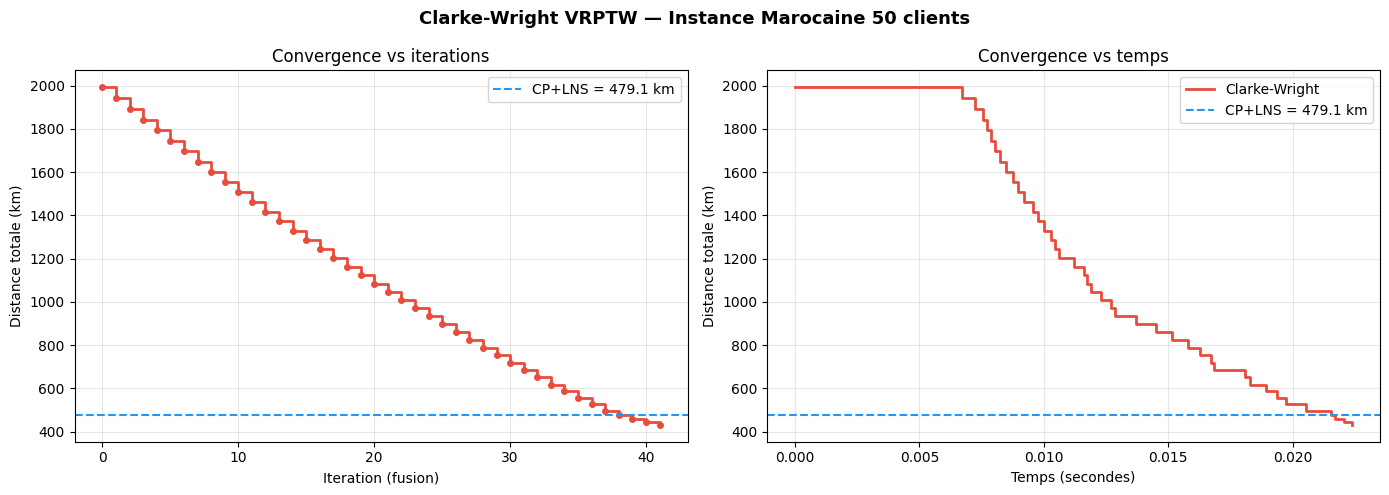

Figure sauvegardee : convergence_CW_maroc50.png


In [15]:
iters = [h[0] for h in history]
dists = [h[1]/1000 for h in history]   # en km
times = [h[3] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Clarke-Wright VRPTW — Instance Marocaine 50 clients', fontsize=13, fontweight='bold')

# Courbe distance vs iteration
ax1 = axes[0]
ax1.step(iters, dists, where='post', color='#E74C3C', linewidth=2)
ax1.plot(iters, dists, 'o', color='#E74C3C', markersize=4)
ax1.axhline(y=LNS_DIST_KM, color='#2196F3', linestyle='--', linewidth=1.5,
            label=f'CP+LNS = {LNS_DIST_KM} km')
ax1.set_xlabel('Iteration (fusion)')
ax1.set_ylabel('Distance totale (km)')
ax1.set_title('Convergence vs iterations')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Courbe distance vs temps
ax2 = axes[1]
ax2.step(times, dists, where='post', color='#E74C3C', linewidth=2, label='Clarke-Wright')
ax2.axhline(y=LNS_DIST_KM, color='#2196F3', linestyle='--', linewidth=1.5,
            label=f'CP+LNS = {LNS_DIST_KM} km')
ax2.set_xlabel('Temps (secondes)')
ax2.set_ylabel('Distance totale (km)')
ax2.set_title('Convergence vs temps')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_CW_maroc50.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : convergence_CW_maroc50.png')

## 6. Détail des tournées

In [16]:
type_nom = {1: 'Triporteur  (300kg)', 2: 'Fourgonnette(1200kg)', 3: 'Camion     (5000kg)'}
type_veh = data['type_vehicule']
demande  = data['demande']
acces    = data['acces']
dist_m   = data['dist']


print('  TOURNEES FINALES — Clarke-Wright Marocain')


for rid, route in sorted(final_routes.items()):
    v_idx   = final_veh[rid]
    v_type  = type_veh[v_idx]
    charge  = sum(demande[c - 1] for c in route)
    dist_r  = route_cost(route, dist_m)

    # Clients avec zone
    clients_str = []
    for c_dzn in route:
        c_0 = c_dzn - 2
        if any(acces[v][c_0] == 0 for v in range(data['K'])):
            if acces[0][c_0] == 0:        # meme triporteur interdit -> tier1
                zone = '[MED1]'
            elif acces[v_idx][c_0] == 0:  # camion interdit
                zone = '[MED2]'
            else:
                zone = '[MED2]'
        else:
            zone = ''
        clients_str.append(f'C{c_dzn-1}{zone}')

    print(f'V{v_idx+1:02d} [{type_nom[v_type]}]')
    print(f'    charge={charge}/{data["capacite"][v_idx]}kg  dist={dist_r/1000:.1f}km')
    print(f'    Depot -> {" -> ".join(clients_str)} -> Depot')
    print()

  TOURNEES FINALES — Clarke-Wright Marocain
V09 [Fourgonnette(1200kg)]
    charge=433/1200kg  dist=22.5km
    Depot -> C2 -> C3 -> C1 -> Depot

V09 [Fourgonnette(1200kg)]
    charge=590/1200kg  dist=43.5km
    Depot -> C4[MED2] -> C50 -> C22 -> C21 -> C29[MED2] -> C43 -> Depot

V01 [Triporteur  (300kg)]
    charge=274/300kg  dist=53.8km
    Depot -> C12[MED2] -> C30 -> Depot

V09 [Fourgonnette(1200kg)]
    charge=1071/1200kg  dist=52.7km
    Depot -> C16 -> C10[MED2] -> C32 -> C34 -> C46 -> C45 -> C49 -> Depot

V09 [Fourgonnette(1200kg)]
    charge=1108/1200kg  dist=44.6km
    Depot -> C23 -> C25 -> C47 -> C27 -> C28[MED2] -> C33 -> C26 -> C41[MED2] -> Depot

V09 [Fourgonnette(1200kg)]
    charge=914/1200kg  dist=55.3km
    Depot -> C24[MED2] -> C5 -> C7 -> C8 -> C9 -> C6 -> C48 -> C20[MED2] -> Depot

V09 [Fourgonnette(1200kg)]
    charge=1140/1200kg  dist=61.6km
    Depot -> C31 -> C35 -> C37 -> C36 -> C11[MED2] -> C14 -> C13[MED2] -> Depot

V01 [Triporteur  (300kg)]
    charge=267/30